# Question 1:  What is the difference between K-Means and Hierarchical Clustering? Provide a use case for each.


# K-Means

- Centroid-based clustering.
- Requires predefined K.
- Iteratively updates cluster centers.
- Efficient for large datasets.

# Hierarchical

- Builds a tree (dendrogram).
- No need to predefine K.
- Agglomerative or divisive approach.
- Better for small datasets.

# Use cases

- K-Means → Customer segmentation
- Hierarchical → Gene similarity analysis

# Question 2: Explain the purpose of the Silhouette Score in evaluating clustering algorithms.

Silhouette Score measures how well each point fits in its cluster.

Range: -1 to +1

+1 → well separated

0 → overlapping

-1 → misclassified

Used to select optimal clustering quality.

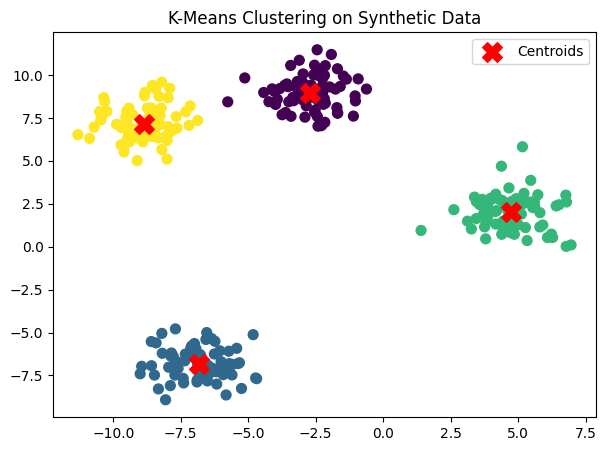

In [5]:
# Dataset:
# Use make_blobs, make_moons, and sklearn.datasets.load_wine() as
# specified.
# Question 6: Generate synthetic data using make_blobs(n_samples=300, centers=4),
# apply KMeans clustering, and visualize the results with cluster centers.
# (Include your Python code and output in the code box below.)



import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic dataset
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Cluster labels and centers
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Step 3: Visualization
plt.figure(figsize=(7,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)

# Plot cluster centers
plt.scatter(centers[:,0], centers[:,1],
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clustering on Synthetic Data")
plt.legend()
plt.show()

In [6]:
# Question 7: Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
# model. Print the number of clusters found (excluding noise).
# (Include your Python code and output in the code box below.)


from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Step 4: Count clusters (exclude noise = -1)
unique_labels = set(labels)
num_clusters = len(unique_labels - {-1})

print("Number of clusters found (excluding noise):", num_clusters)


Number of clusters found (excluding noise): 0


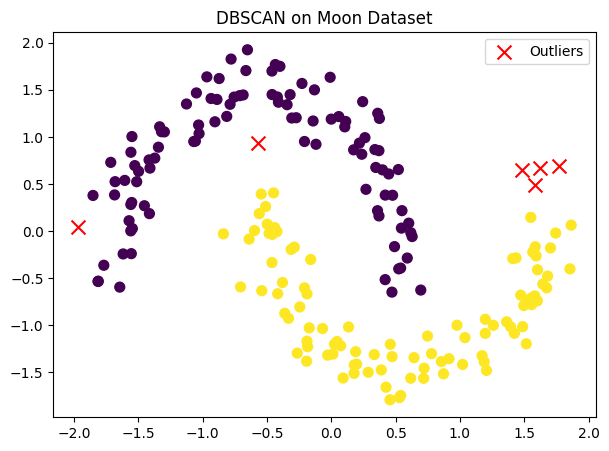

In [9]:
# Question 8: Generate moon-shaped synthetic data using
# make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
# the plot.
# (Include your Python code and output in the code box below.)



import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Step 1: Generate moon-shaped dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Step 2: Scale data (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Step 4: Identify outliers (noise = -1)
outliers = labels == -1

# Step 5: Plot clusters
plt.figure(figsize=(7,5))

# Plot clustered points
plt.scatter(X_scaled[~outliers, 0], X_scaled[~outliers, 1],
            c=labels[~outliers], cmap='viridis', s=50)

# Plot outliers in red
plt.scatter(X_scaled[outliers, 0], X_scaled[outliers, 1],
            c='red', marker='x', s=100, label='Outliers')

plt.title("DBSCAN on Moon Dataset")
plt.legend()
plt.show()


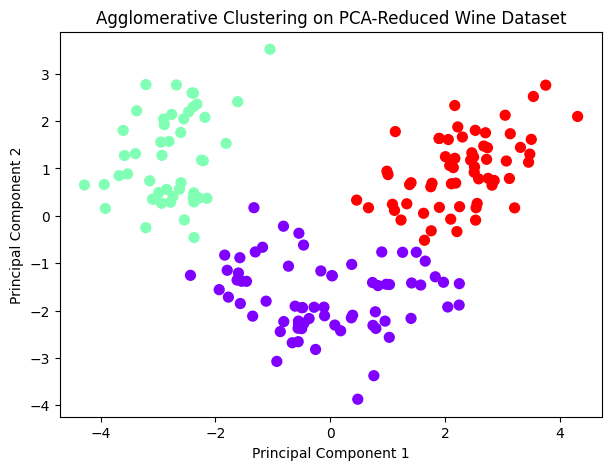

In [10]:
# Question 9: Load the Wine dataset, reduce it to 2D using PCA, then apply
# Agglomerative Clustering and visualize the result in 2D with a scatter plot.
# (Include your Python code and output in the code box below.)




import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X_pca)

# Step 5: Visualization
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='rainbow', s=50)
plt.title("Agglomerative Clustering on PCA-Reduced Wine Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

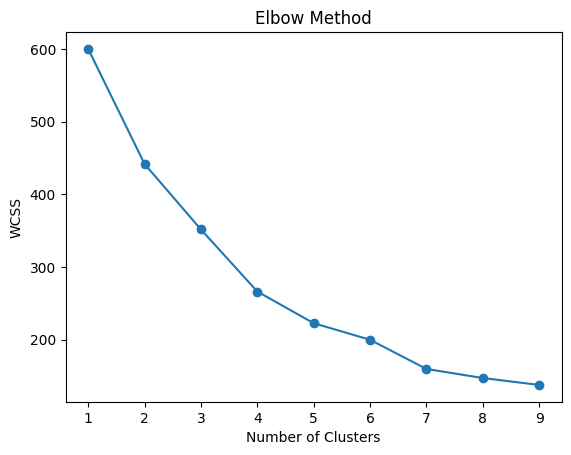

Silhouette Score: 0.29286680043337904


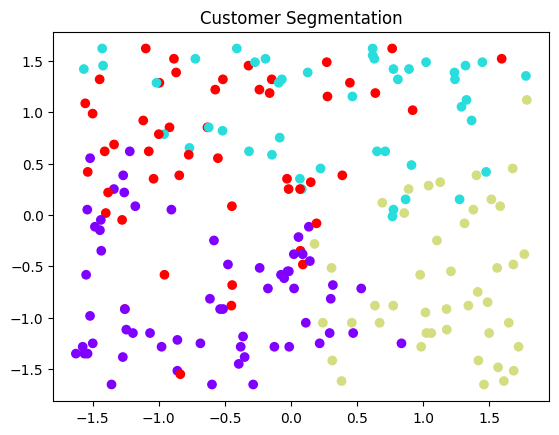

In [11]:
# Question 10: You are working as a data analyst at an e-commerce company. The
# marketing team wants to segment customers based on their purchasing behavior to run
# targeted promotions. The dataset contains customer demographics and their product
# purchase history across categories.
# Describe your real-world data science workflow using clustering:
# ● Which clustering algorithm(s) would you use and why?
# ● How would you preprocess the data (missing values, scaling)?
# ● How would you determine the number of clusters?
# ● How would the marketing team benefit from your clustering analysis?
# (Include your Python code and output in the code box below.)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Create synthetic customer dataset
np.random.seed(42)
data = pd.DataFrame({
    'Age': np.random.randint(18, 60, 200),
    'Annual_Income': np.random.randint(20000, 120000, 200),
    'Spending_Score': np.random.randint(1, 100, 200)
})

# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# -------- Elbow Method --------
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# -------- Train Final Model --------
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(scaled_data)

# Silhouette Score
score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", score)

# Visualization (2 features for demo)
plt.scatter(scaled_data[:,1], scaled_data[:,2], c=labels, cmap='rainbow')
plt.title("Customer Segmentation")
plt.show()